# IPL Season Trends
Tracking how the game itself has evolved across 16 seasons (2008–2024) — scoring
patterns, aggression, toss dynamics, and player consistency over time.

## 1. Setup

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

delivery = pd.read_csv('Resources/deliveries.csv')
matches = pd.read_csv('Resources/matches.csv')

merged_full = delivery.merge(
    matches[['id','season']], left_on='match_id', right_on='id'
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Powerplay Scoring Evolution (2008–2024)

The first six overs often set the tone for an innings. This analysis tracks the
average powerplay run rate across seasons to see whether teams have become more
aggressive at the start of an innings over time.

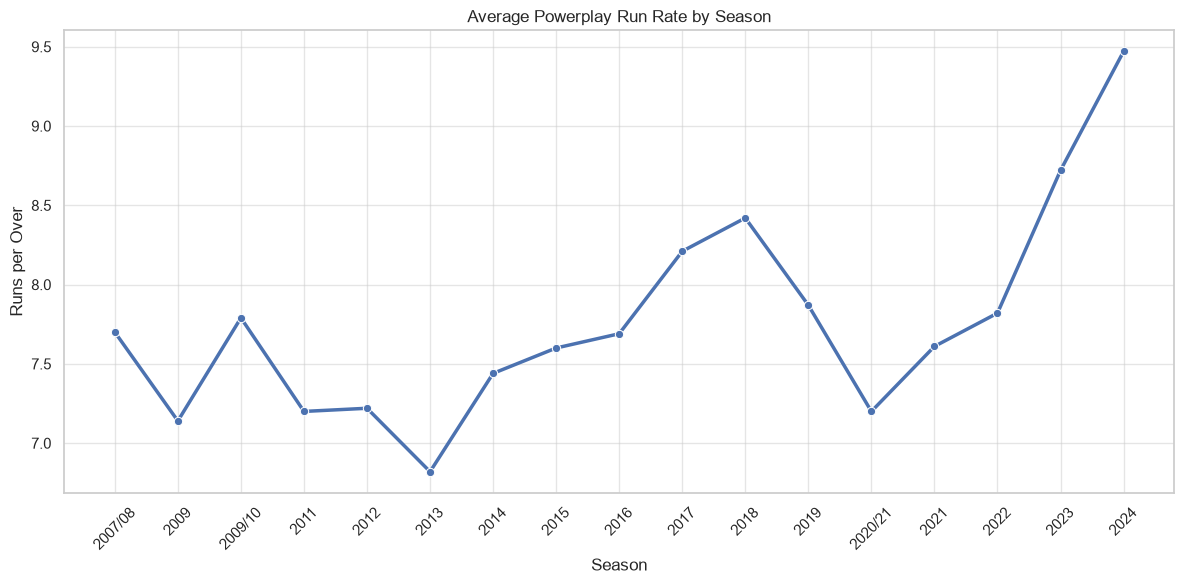

In [7]:
powerplay = merged_full[merged_full['over'] <= 5]
pp_innings = (powerplay.groupby(['season', 'match_id', 'inning'])['total_runs'].sum().reset_index(name='powerplay_runs'))

pp_by_season = (pp_innings.groupby('season')['powerplay_runs'].mean().round(2))
pp_run_rate = (pp_by_season / 6).round(2)

#Visualisation
plt.figure(figsize=(12, 6))
sns.lineplot(x=pp_run_rate.index,y=pp_run_rate.values,marker='o',linewidth=2.5)

plt.title('Average Powerplay Run Rate by Season')
plt.xlabel('Season')
plt.ylabel('Runs per Over')
plt.xticks(pp_run_rate.index, rotation=45)

plt.tight_layout()
plt.savefig('charts/powerplay_evolution.png')
plt.show()

**Observations:**

- Powerplay scoring has generally increased over the years, indicating teams have adopted a more aggressive approach in the first six overs.
- Any noticeable jumps or dips correspond to specific seasons, suggesting the influence of factors such as rule changes, playing conditions, or evolving batting strategies.
- Despite some year-to-year fluctuations, the long-term trend clearly points toward higher scoring rates in the powerplay.

## 3. Average First Innings Score by Season

Scoring trends are often best reflected by first innings totals, as they are not
affected by chase situations. This analysis examines how the average first innings
score has changed across IPL seasons.

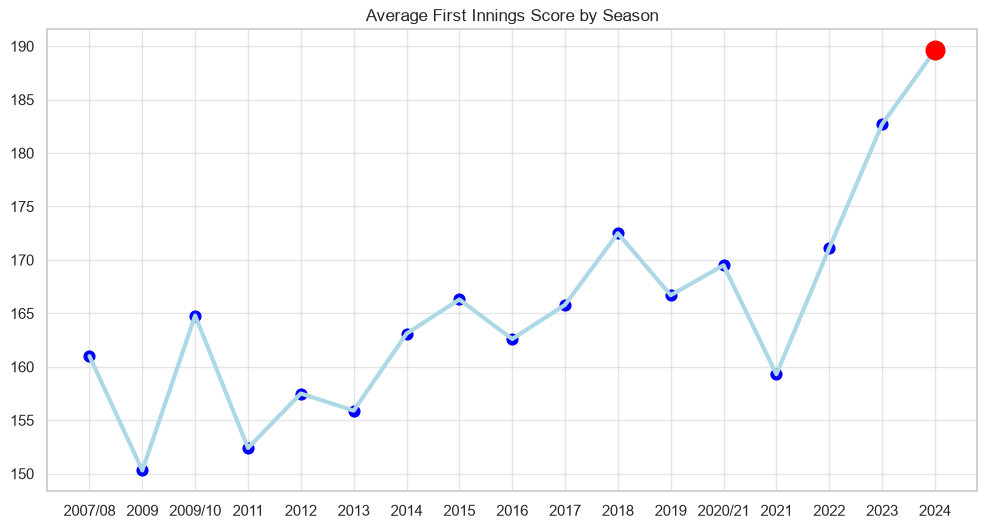

In [8]:
# First innings of completed matches
first_innings = (delivery[delivery['inning'] == 1].groupby('match_id')['total_runs'].sum().reset_index(name='first_innings_score'))
first_innings = first_innings.merge(matches[['id', 'season']],left_on='match_id',right_on='id')
avg_score = (first_innings.groupby('season')['first_innings_score'].mean().round(1))

#Visualisation
plt.figure(figsize=(12,6))
plt.plot(avg_score.index,avg_score.values,color='lightblue',linewidth=3)
plt.scatter(avg_score.index[:-1],avg_score.values[:-1],s=60,color='blue')
plt.scatter(avg_score.index[-1],avg_score.values[-1],s=180,color='red',zorder=5)
plt.title('Average First Innings Score by Season')
plt.savefig("charts/average_first_innings_score.png")
plt.show()

**Observations:**

- Average first innings scores have generally increased over the years, reflecting the IPL's shift toward higher-scoring matches.
- The steepest increases occur in the later seasons, coinciding with increasingly aggressive batting strategies.
- Although some seasons show slight declines, the long-term trend is clearly upward, indicating that teams now post significantly larger totals than in the league's early years.

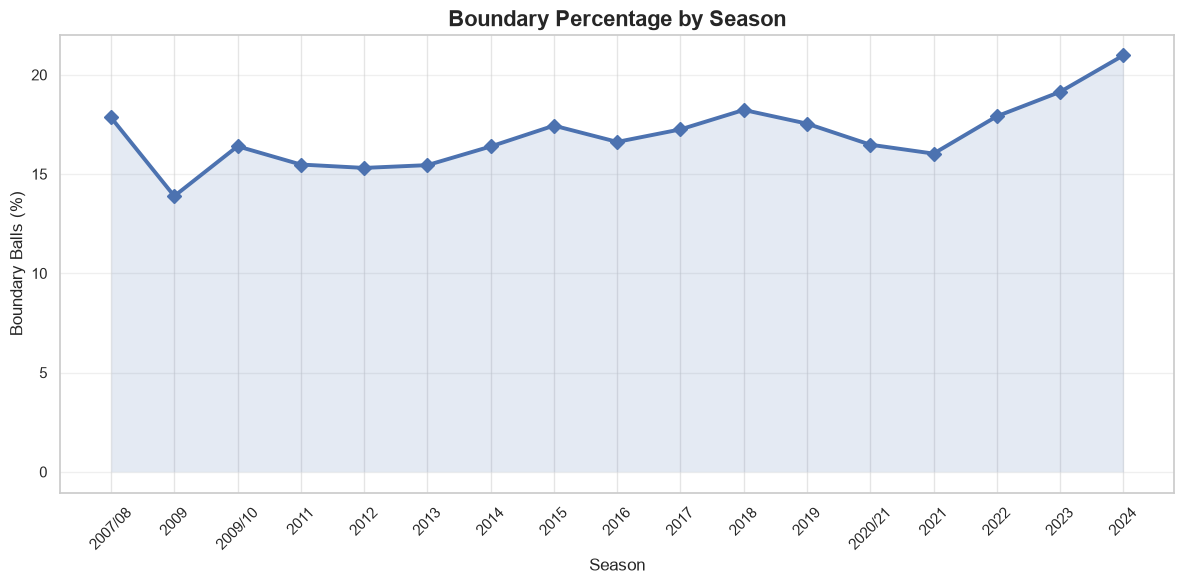

In [9]:
# Exclude wides as they are not legal deliveries
legal_deliveries = merged_full[merged_full['extras_type'] != 'wides']

# Deliveries that resulted in a boundary
boundary_balls = legal_deliveries[legal_deliveries['batsman_runs'].isin([4, 6])]

# Percentage of legal deliveries that were boundaries
boundary_pct = (
    boundary_balls.groupby('season').size()
    / legal_deliveries.groupby('season').size()* 100).round(2)
#---------------------------------------------------------------
#Visualisation

plt.figure(figsize=(12, 6))

plt.plot(boundary_pct.index,boundary_pct.values,linewidth=2.8,marker='D',markersize=7)
plt.fill_between(boundary_pct.index,boundary_pct.values,alpha=0.15)

plt.title('Boundary Percentage by Season', fontsize=16, weight='bold')
plt.xlabel('Season')
plt.ylabel('Boundary Balls (%)')

plt.xticks(boundary_pct.index, rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('charts/boundary_percentage.png')
plt.show()

**Observations:**

- The percentage of legal deliveries resulting in boundaries has increased from approximately **15% in the early seasons** to around **20% in recent seasons**, indicating a clear shift toward more aggressive batting.
- The increase in boundary frequency aligns with the rise in average first innings scores, suggesting that higher totals are driven partly by more frequent boundary hitting.
- Despite this upward trend, the majority of deliveries still do not result in boundaries, highlighting that strike rotation and running between the wickets remain important aspects of T20 batting.

## 5. Toss Impact Over Time

Winning the toss is often considered an advantage in T20 cricket, particularly under
certain playing conditions. This analysis examines how often the team winning the
toss also won the match, and whether the influence of the toss has changed across
IPL seasons.

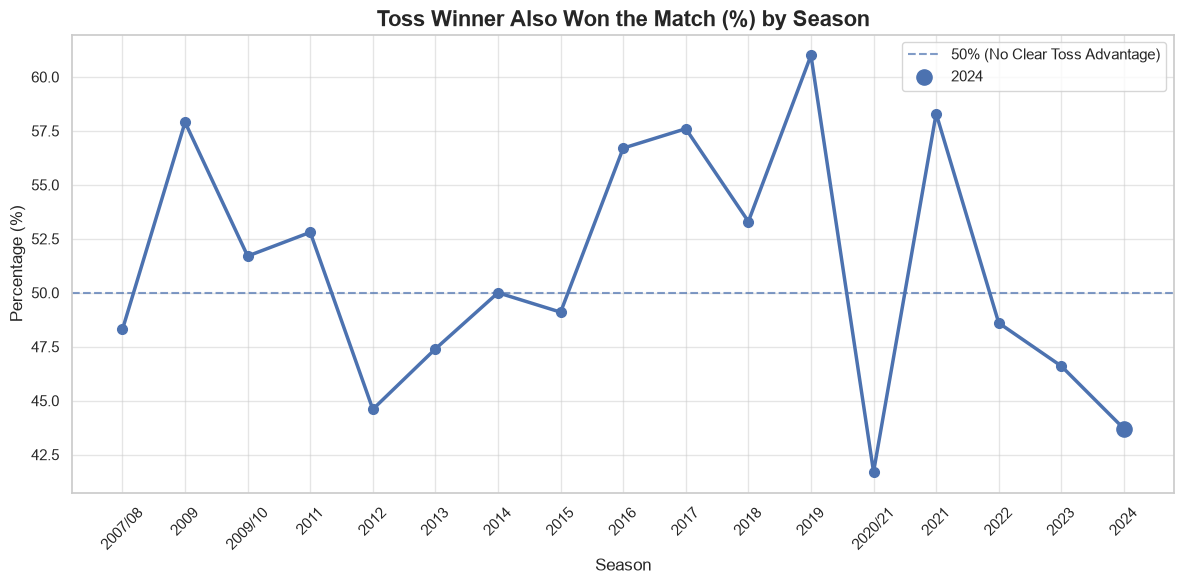

In [10]:
# Exclude matches with no result
valid_matches = matches[matches['winner'].notna()].copy()
# Check if the toss winner also won the match
valid_matches['toss_won_match'] = (valid_matches['toss_winner'] == valid_matches['winner'])

# Calculate season-wise percentage
toss_impact = (valid_matches.groupby('season')['toss_won_match'].mean().mul(100).round(1))
#--------------------------------------------------------------------------------------
#Visualisation
plt.figure(figsize=(12,6))

plt.plot(toss_impact.index,toss_impact.values,linewidth=2.5,marker='o',markersize=7)

# Benchmark: 50% means toss provides no clear advantage
plt.axhline(50,linestyle='--',linewidth=1.5,alpha=0.7,label='50% (No Clear Toss Advantage)')

# Highlight the latest season
plt.scatter(toss_impact.index[-1],toss_impact.values[-1],s=120,zorder=5,label='2024')

plt.title('Toss Winner Also Won the Match (%) by Season', fontsize=16, weight='bold')
plt.xlabel('Season')
plt.ylabel('Percentage (%)')

plt.xticks(toss_impact.index, rotation=45)
plt.legend()

plt.tight_layout()
plt.savefig('charts/toss_impact_over_time.png')
plt.show()

**Observations:**

- The percentage of matches won by the toss-winning team fluctuates noticeably from season to season, with no consistent upward or downward trend.
- In most seasons, the value remains close to 50%, suggesting that winning the toss alone is not a reliable predictor of match outcome.
- While certain seasons show a stronger toss advantage, the long-term trend indicates that team performance has a greater influence on match results than the toss itself.

## 6. Batting First vs Chasing Success

Scoring trends can also influence match strategy. This analysis compares the
percentage of matches won while batting first and while chasing across IPL
seasons to examine how the balance between the two approaches has evolved over
time.

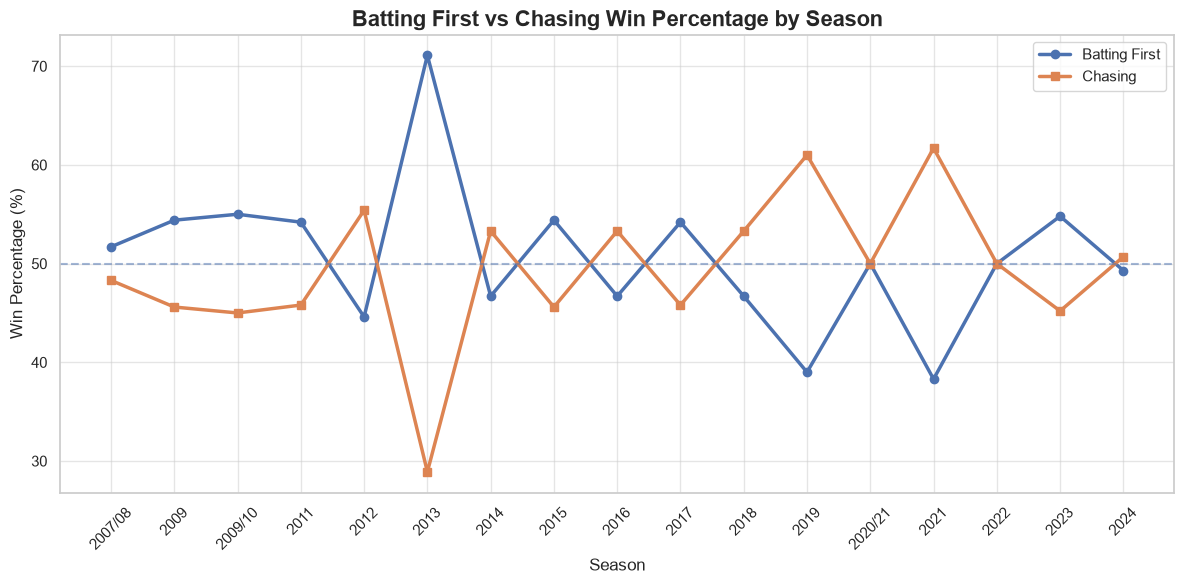

In [13]:
# Exclude matches with no result
valid_matches = matches[matches['winner'].notna()].copy()

# Identify whether the winner batted first
valid_matches['batting_first_won'] = (
    valid_matches['winner'] == valid_matches['team1']
)
batting_first = (valid_matches.groupby('season')['batting_first_won'].mean().mul(100).round(1))
chasing = (100 - batting_first).round(1)
#-----------------------------------------------------------------------------------
#Visualisation
plt.figure(figsize=(12,6))

plt.plot(batting_first.index,batting_first.values,marker='o',linewidth=2.5,label='Batting First')
plt.plot(chasing.index,chasing.values,marker='s',linewidth=2.5,label='Chasing')
plt.axhline(50, linestyle='--', alpha=0.5)
plt.title('Batting First vs Chasing Win Percentage by Season',fontsize=16, weight='bold')
plt.xlabel('Season')
plt.ylabel('Win Percentage (%)')

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.savefig('charts/batting_first_vs_chasing.png')
plt.show()

**Observations:**

- The balance between batting first and chasing has varied across seasons, with neither strategy maintaining a consistent long-term advantage.
- Several seasons show a clear preference for one approach, highlighting the influence of pitch conditions, team composition and tactical trends.
- Overall, the IPL appears to remain well balanced, with successful teams adapting their strategy to match conditions rather than relying solely on batting order.

## Key Findings

- Powerplay scoring has increased steadily over the years, reflecting a more aggressive approach during the first six overs.
- Average first innings scores have risen across seasons, showing that modern IPL teams consistently post higher totals.
- Boundary frequency has increased from roughly **15%** to **20%** of legal deliveries, indicating that power hitting has become a larger contributor to scoring.
- The relationship between winning the toss and winning the match fluctuates considerably from season to season, suggesting that the toss alone is not a reliable predictor of success.
- Overall, the IPL has evolved into a higher-scoring and more aggressive competition, while strategic factors such as the toss and batting order remain dependent on season-specific conditions rather than showing a consistent long-term trend.